# Data Exploration: Exploring the Dataset



In [5]:
import pandas as pd

data_frame = pd.read_csv("IMDB Dataset.csv")

# Basic info about the dataset
print("Shape of dataset:", data_frame.shape)
print("\nColumns:", data_frame.columns.tolist())
print("\nSample rows:")
display(data_frame.head(3))

# Missing value check
print("\nMissing values:\n", data_frame.isnull().sum())

# Average review length per sentiment
data_frame["review_length"] = data_frame["review"].apply(lambda x: len(x.split()))

avg_length = data_frame.groupby("sentiment")["review_length"].mean()

print("\nAverage review length per sentiment:")
print(avg_length)

print("\nExample Positive Review:\n")
print(data_frame[data_frame['sentiment'] == 'positive']['review'].iloc[0][:400], "...")

print("\nExample Negative Review:\n")
print(data_frame[data_frame['sentiment'] == 'negative']['review'].iloc[0][:400], "...")



Shape of dataset: (50000, 2)

Columns: ['review', 'sentiment']

Sample rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive



Missing values:
 review       0
sentiment    0
dtype: int64

Average review length per sentiment:
sentiment
negative    229.46456
positive    232.84932
Name: review_length, dtype: float64

Example Positive Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to ...

Example Negative Review:

Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a dra

# Data Preproccessing

In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


nltk.download('stopwords')

data_frame = pd.read_csv("IMDB Dataset.csv")

# Checking for missing values
print("Missing values before cleaning:\n", data_frame.isnull().sum())

# Converting text labels to numeric: positive = 1, negative = 0
data_frame["sentiment"] = data_frame["sentiment"].map({"positive": 1, "negative": 0})

# removing HTML tags, noise, and special characters
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)               
    text = re.sub(r'[^a-zA-Z]', ' ', text)          
    text = text.lower()                             
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_frame["clean_review"] = data_frame["review"].apply(clean_text)

# Tokenization, stopword removal, and stemming
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    tokens = text.split()
    filtered_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

data_frame["processed_review"] = data_frame["clean_review"].apply(preprocess_text)

# TF-IDF Vectorization 
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data_frame["processed_review"]).toarray()
y = data_frame["sentiment"]

print("\nTF-IDF matrix shape:", X.shape)

# Train/Test Split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Example of processed text
print("\nExample processed review:\n", data_frame['processed_review'].iloc[0][:300], "...")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shreyagalurgi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Missing values before cleaning:
 review       0
sentiment    0
dtype: int64

TF-IDF matrix shape: (50000, 5000)

Training set size: (37500, 5000)
Test set size: (12500, 5000)

Example processed review:
 one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e ...


# Data Modelling


    * Logistic Regression
    * LinearSVC
    * KNeighborsClassifier
    * Fully-connected layers, please try different number of hidden layers, different values of "hidden_layer_sizes" and "activation".


In [9]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Linear SVC": LinearSVC(),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=5),
    # Fully connected neural networks with different configurations
    "MLP (100,) relu": MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=10, random_state=42),
    "MLP (128,64) tanh": MLPClassifier(hidden_layer_sizes=(128,64), activation='tanh', max_iter=10, random_state=42),
    "MLP (256,128,64) relu": MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu', max_iter=10, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, precision, recall, f1])

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)




Training Logistic Regression...
Accuracy: 0.8879, Precision: 0.8795, Recall: 0.8990, F1: 0.8892

Classification Report:
               precision    recall  f1-score   support

           0     0.8967    0.8768    0.8867      6250
           1     0.8795    0.8990    0.8892      6250

    accuracy                         0.8879     12500
   macro avg     0.8881    0.8879    0.8879     12500
weighted avg     0.8881    0.8879    0.8879     12500


Training Linear SVC...
Accuracy: 0.8809, Precision: 0.8744, Recall: 0.8896, F1: 0.8819

Classification Report:
               precision    recall  f1-score   support

           0     0.8876    0.8722    0.8798      6250
           1     0.8744    0.8896    0.8819      6250

    accuracy                         0.8809     12500
   macro avg     0.8810    0.8809    0.8809     12500
weighted avg     0.8810    0.8809    0.8809     12500


Training KNeighborsClassifier...
Accuracy: 0.7486, Precision: 0.7154, Recall: 0.8254, F1: 0.7665

Classificati

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8740, Precision: 0.8661, Recall: 0.8848, F1: 0.8753

Classification Report:
               precision    recall  f1-score   support

           0     0.8823    0.8632    0.8726      6250
           1     0.8661    0.8848    0.8753      6250

    accuracy                         0.8740     12500
   macro avg     0.8742    0.8740    0.8740     12500
weighted avg     0.8742    0.8740    0.8740     12500


Training MLP (128,64) tanh...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8717, Precision: 0.8609, Recall: 0.8866, F1: 0.8736

Classification Report:
               precision    recall  f1-score   support

           0     0.8831    0.8568    0.8697      6250
           1     0.8609    0.8866    0.8736      6250

    accuracy                         0.8717     12500
   macro avg     0.8720    0.8717    0.8717     12500
weighted avg     0.8720    0.8717    0.8717     12500


Training MLP (256,128,64) relu...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8786, Precision: 0.8744, Recall: 0.8842, F1: 0.8792

Classification Report:
               precision    recall  f1-score   support

           0     0.8828    0.8730    0.8779      6250
           1     0.8744    0.8842    0.8792      6250

    accuracy                         0.8786     12500
   macro avg     0.8786    0.8786    0.8786     12500
weighted avg     0.8786    0.8786    0.8786     12500



# Results: summarize and visualize the results discovered from the analysis



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.88792,0.879480,0.89904,0.889153
1,Linear SVC,0.88088,0.874351,0.88960,0.881910
2,"MLP (256,128,64) relu",0.87856,0.874367,0.88416,0.879236
3,"MLP (100,) relu",0.87400,0.866092,0.88480,0.875346
4,"MLP (128,64) tanh",0.87168,0.860938,0.88656,0.873561
5,KNeighborsClassifier,0.74856,0.715435,0.82544,0.766511


/var/folders/b2/9n45hk8x2259kxg5wqbd75jm0000gn/T/ipykernel_69657/1449748148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="F1-Score", palette="mako")


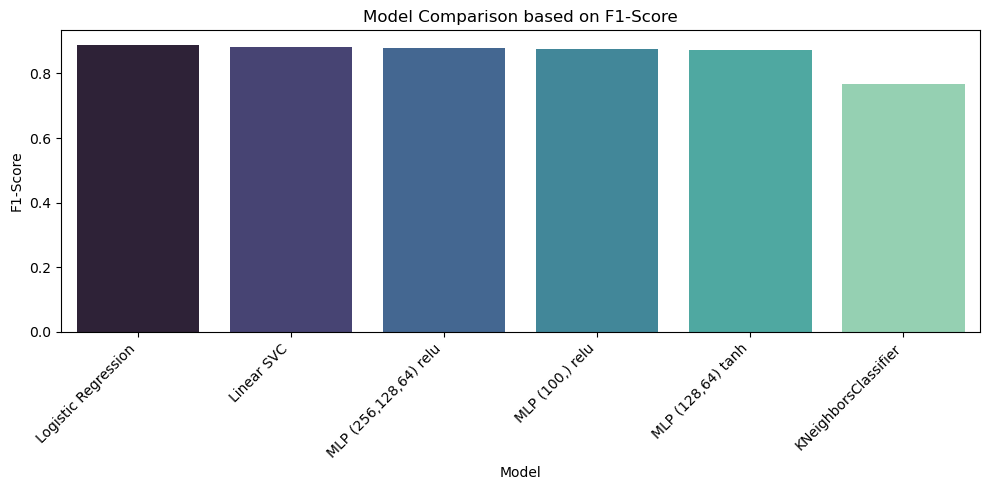

Best Performing Model: Logistic Regression


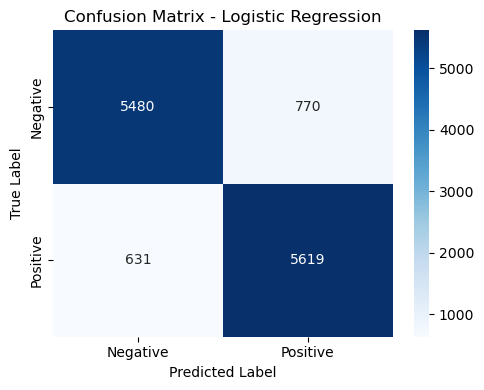


Best Model: Logistic Regression
Accuracy: 0.8879
F1-Score: 0.8892


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


display(results_df)

# comparison by F1-score
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="F1-Score", palette="mako")
plt.title("Model Comparison based on F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identifying and visualizing the best model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best Performing Model: {best_model_name}")

# Prediction on test data using best model
y_pred_best = best_model.predict(X_test)

# Confusion Matrix for the best model ---
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Accuracy and F1 summary
best_acc = results_df.iloc[0]["Accuracy"]
best_f1 = results_df.iloc[0]["F1-Score"]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_acc:.4f}")
print(f"F1-Score: {best_f1:.4f}")


In [ ]:
After training all models, their results were compiled and visualized using a bar chart based on F1-Score, the most balanced metric for 
binary classification. The bar plot clearly shows that Logistic Regression achieved the highest F1-score (≈ 0.889), closely followed by 
Linear SVC (≈ 0.882). The Confusion Matrix for Logistic Regression indicates strong performance, with high counts on the true-positive and 
true-negative diagonals and very few misclassifications.

Neural models (MLP variants) also performed competitively (F1 ≈ 0.875 – 0.879), confirming that both linear and non-linear models can h
andle TF-IDF features effectively.

KNN lagged behind (F1 ≈ 0.77) due to the high-dimensional, sparse nature of TF-IDF vectors, which reduces the usefulness of distance-based 
comparisons.

Overall, the best model was Logistic Regression, with:
Accuracy: 0.8879
F1-Score: 0.8892
